In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_dir = r"D:\Project\ML project\smart-eye-diagnosis\data\raw\test"

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # 🔥 VERY IMPORTANT
)

Found 763 images belonging to 4 classes.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tensorflow import keras

# Load model
model = keras.models.load_model("../models/final_model.h5")

# Get predictions
y_true = test_data.classes
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_data.class_indices.keys())

24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 459ms/step


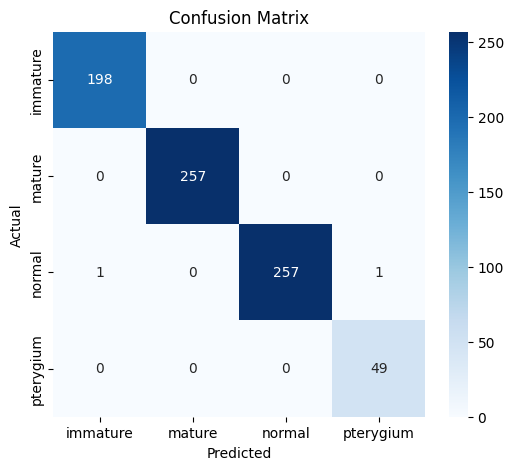

In [7]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [8]:
# 📊 2. CLASSIFICATION REPORT
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    immature       0.99      1.00      1.00       198
      mature       1.00      1.00      1.00       257
      normal       1.00      0.99      1.00       259
   pterygium       0.98      1.00      0.99        49

    accuracy                           1.00       763
   macro avg       0.99      1.00      1.00       763
weighted avg       1.00      1.00      1.00       763



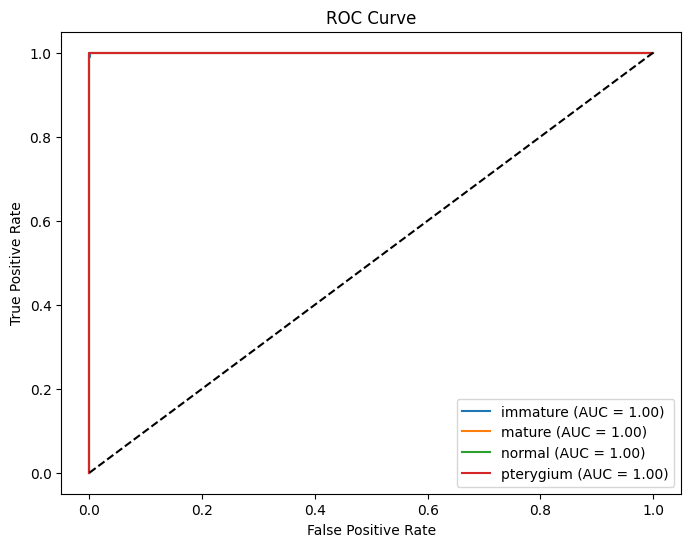

In [9]:
# 📈 3. ROC CURVE (MULTI-CLASS)
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

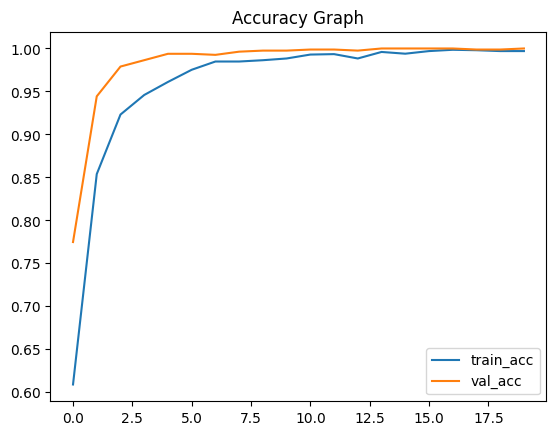

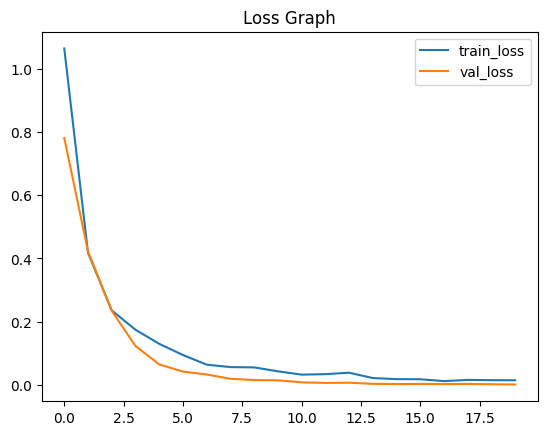

In [17]:
# 📊 4. TRAINING GRAPH
# accuracy
import json
import matplotlib.pyplot as plt

with open("models/history.json", "r") as f:
    history = json.load(f)

plt.plot(history['accuracy'], label='train_acc')
plt.plot(history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history['loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

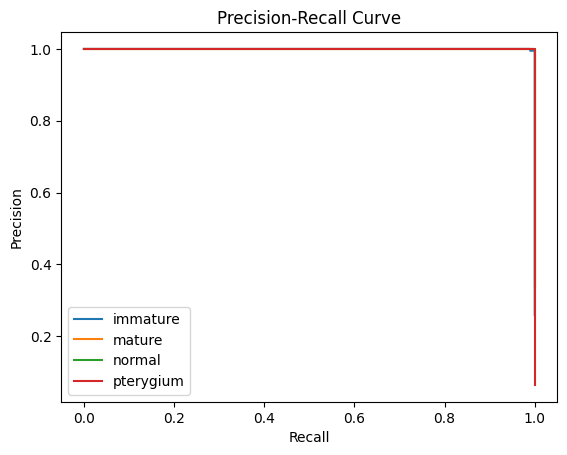

In [11]:
# 📊 5. PRECISION-RECALL CURVE
from sklearn.metrics import precision_recall_curve

for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()